In [282]:
import pandas as pd
import numpy as np
import seaborn as sns

In [283]:
df=pd.read_csv('car_price_prediction.csv')

In [284]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2267,2268,Honda,2014,5.7,Electric,Automatic,10236,New,25551.25,Civic
2488,2489,BMW,2019,1.6,Petrol,Automatic,222129,Like New,16102.78,X3
1960,1961,Toyota,2001,4.6,Diesel,Automatic,216897,New,90870.69,Corolla
1718,1719,Ford,2012,5.4,Hybrid,Manual,122196,Used,69005.74,Focus
1700,1701,Mercedes,2008,4.5,Diesel,Automatic,191707,New,28450.65,E-Class


In [285]:
print(df['Brand'].value_counts())
print(df['Fuel Type'].value_counts())
print(df['Transmission'].value_counts())
print(df['Condition'].value_counts())

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64
Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64
Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64
Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64


In [286]:
df.replace({'Condition':{'Used':0,'Like New':1,'New':2}},inplace=True)
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)
df.replace({'Fuel Type':{'Diesel':0,'Petrol':1,'Electric':2,'Hybrid':3}},inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_16144\1547560127.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Condition':{'Used':0,'Like New':1,'New':2}},inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16144\1547560127.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16144\1547560127.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retai

In [287]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,1,0,114832,2,26613.92,Model X
1,2,BMW,2018,4.4,2,0,143190,0,14679.61,5 Series
2,3,Audi,2013,4.5,2,0,181601,2,44402.61,A4
3,4,Tesla,2011,4.1,0,1,68682,2,86374.33,Model Y
4,5,Ford,2009,2.6,0,0,223009,1,73577.10,Mustang


In [288]:
df=df.drop(['Car ID','Brand','Model'],axis=1)

In [289]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
df[['Mileage','Price']]= ms.fit_transform(df[['Mileage','Price']])

In [290]:
df.head()

,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price
0,2016,2.3,1,0,0.382785,2,0.227465
1,2018,4.4,2,0,0.477326,0,0.101803
2,2013,4.5,2,0,0.605384,2,0.414771
3,2011,4.1,0,1,0.228927,2,0.856712
4,2009,2.6,0,0,0.743432,1,0.721964


In [291]:
X = df.drop(columns=['Price'])
y=df['Price']

In [292]:
print(f"Rows in X: {X.shape[0]}, Rows in y: {y.shape[0]}")

Rows in X: 2500, Rows in y: 2500


In [293]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [294]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
lr=LinearRegression()
lr.fit(x_train, y_train)
y_pred=lr.predict(x_test)
print(r2_score(y_pred,y_test))

-350.76381491059254


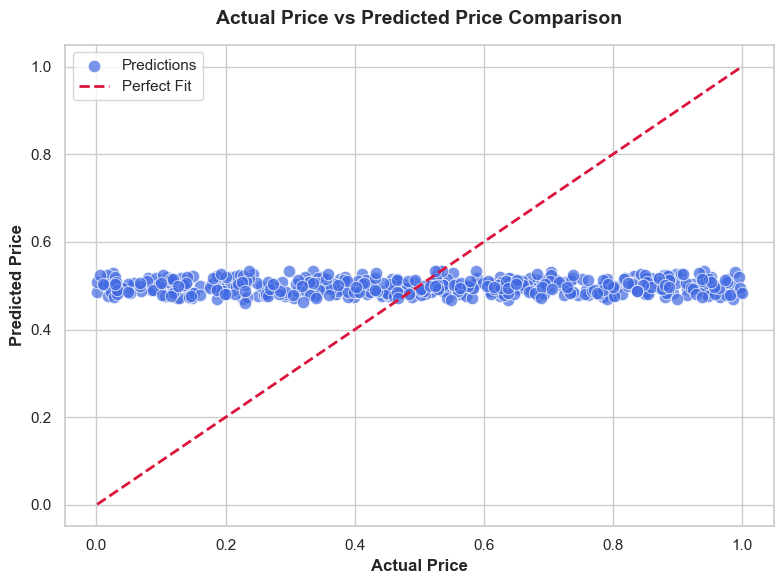

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot ka size aur style set karein
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# 2. Scatter plot banayein (Actual vs Predicted)
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.7, edgecolors='w', s=80, label='Predictions')

# 3. Ek Perfect Prediction (Ideal) line draw karein
# Agar saare points is line par hain, toh model 100% accurate hai
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Fit')

# 4. Labels aur Title add karein
plt.xlabel('Actual Price', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price', fontsize=12, fontweight='bold')
plt.title('Actual Price vs Predicted Price Comparison', fontsize=14, fontweight='bold', pad=15)

# 5. Legend show karein aur graph display karein
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()
